# EDA

The SQL in `sql/` does the heavy lifting. This notebook runs those queries and plots what's worth plotting. Build the db first with `python sql/load_db.py` from the repo root.

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

con = sqlite3.connect("../churn.db")

def q(name):
    with open(f"../sql/{name}") as f:
        return pd.read_sql(f.read(), con)

In [2]:
q("01_churn_rate.sql")

,customers,churned,churn_pct
0,10000,2037,20.4


20.4% overall. One in five customers gone - that's the baseline every cut below gets compared against.

In [3]:
q("02_geography.sql")

,geography,customers,churned,churn_pct
0,Germany,2509,814,32.4
1,Spain,2477,413,16.7
2,France,5014,810,16.2


In [4]:
q("03_gender.sql")

,gender,customers,churn_pct
0,Female,4543,25.1
1,Male,5457,16.5


Germany churns at double the rate of France and Spain (32% vs ~16%), and it's a quarter of the book. Women churn more than men, 25% vs 17%. Geography is the bigger gap.

In [5]:
df = q("04_age_bands.sql")
df

,age_band,customers,churn_pct
0,18-29,1641,7.6
1,30-39,4346,10.9
2,40-49,2618,30.8
3,50-59,869,56.0
4,60+,526,27.9


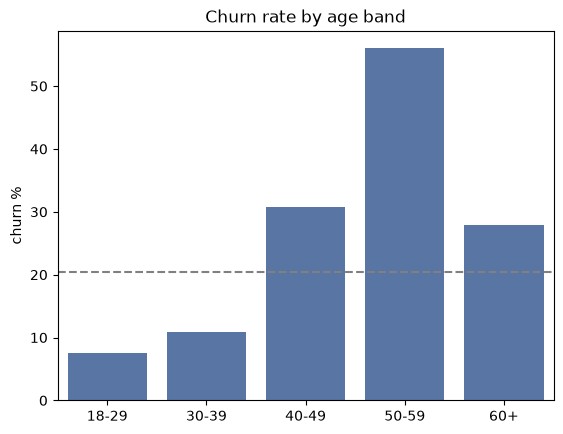

In [6]:
ax = sns.barplot(df, x="age_band", y="churn_pct", color="#4c72b0")
ax.axhline(20.4, ls="--", c="gray")
ax.set(title="Churn rate by age band", xlabel="", ylabel="churn %")
plt.savefig("../figures/churn_by_age.png", dpi=150, bbox_inches="tight")

Strongest single cut so far. 50-59 year olds churn at 56%, nearly triple base rate. And it's not monotonic - 60+ falls back to 28%. Age needs to enter the model in a way that can bend.

In [7]:
q("05_tenure.sql")

,tenure_band,customers,churn_pct
0,0-2,2496,21.2
1,3-5,3010,20.8
2,6-8,3020,18.9
3,9-10,1474,21.3


Tenure is flat, 19-21% in every band. Years with the bank buy nothing.

In [8]:
df = q("06_products.sql")
df

,num_products,customers,churn_pct
0,1,5084,27.7
1,2,4590,7.6
2,3,266,82.7
3,4,60,100.0


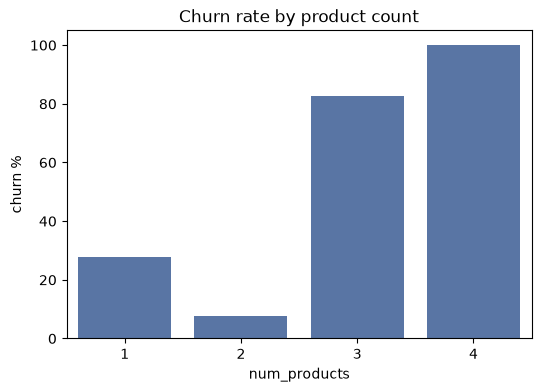

In [9]:
plt.figure(figsize=(6, 4))
ax = sns.barplot(df, x="num_products", y="churn_pct", color="#4c72b0")
ax.set(title="Churn rate by product count", ylabel="churn %")
plt.savefig("../figures/churn_by_products.png", dpi=150, bbox_inches="tight")

Two products is the sweet spot at 7.6%. One product churns at 28% - under-engaged. Three and four products churn at 83% and 100%, which smells like forced cross-sells or fee pain, though those groups are small (266 and 60 customers).

In [10]:
q("07_activity.sql")

,is_active,customers,churn_pct
0,0,4849,26.9
1,1,5151,14.3


In [11]:
q("08_balance.sql")

,exited,customers,avg_balance,zero_balance_pct
0,0,7963,72745.0,39.1
1,1,2037,91109.0,24.5


Inactive members churn at 27% vs 14% for active. And churners hold more money: average balance 91k vs 73k, and only 24% of churners had a zero balance vs 39% of stayers. The bank is losing funded accounts, not empty ones.

Text(0.5, 1.0, 'Balance (non-zero), churners vs stayers')

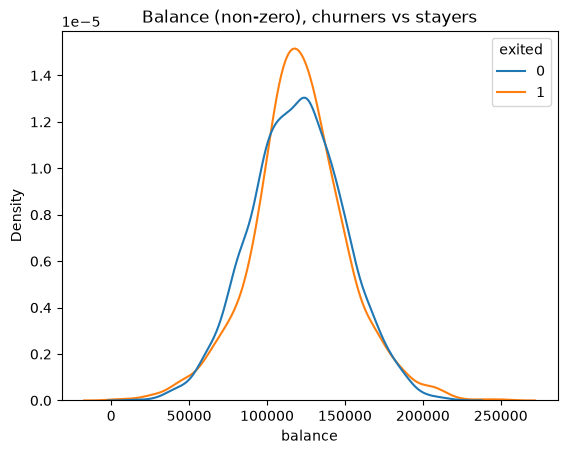

In [12]:
bal = pd.read_sql("select balance, exited from customers where balance > 0", con)
sns.kdeplot(bal, x="balance", hue="exited", common_norm=False)
plt.title("Balance (non-zero), churners vs stayers")

## Cross-cuts

,geography,is_active,customers,churn_pct
0,France,0,2423,21.1
1,France,1,2591,11.5
2,Germany,0,1261,41.1
3,Germany,1,1248,23.7
4,Spain,0,1165,23.3
5,Spain,1,1312,10.7


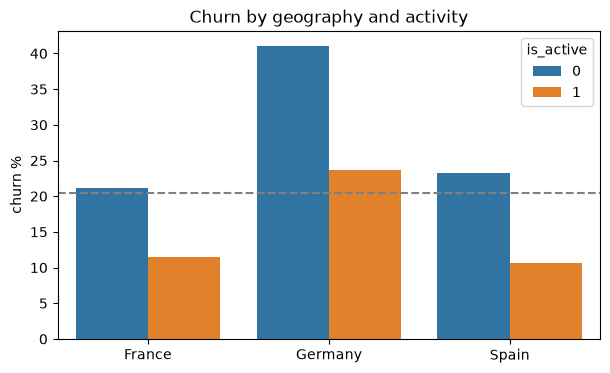

In [13]:
df = q("09_geo_x_activity.sql")
plt.figure(figsize=(7, 4))
ax = sns.barplot(df, x="geography", y="churn_pct", hue="is_active")
ax.axhline(20.4, ls="--", c="gray")
ax.set(title="Churn by geography and activity", xlabel="", ylabel="churn %")
plt.savefig("../figures/geo_x_activity.png", dpi=150, bbox_inches="tight")
df

Even *active* German customers churn at 24% - above overall base rate, and worse than inactive customers in France or Spain. Whatever is wrong in Germany, it isn't just disengagement.

In [14]:
q("10_age_x_activity.sql").pivot(index="age_band", columns="is_active", values="churn_pct")

is_active,0,1
age_band,,
18-29,9.8,5.4
30-39,13.6,8.2
40-49,38.0,22.6
50-59,81.2,37.1
60+,85.6,12.5


Inactive 50-59s churn at 81%, inactive 60+ at 86%. Meanwhile active 60+ churn at just 12.5% - activity is enormously protective for older customers. Older + inactive is basically a goodbye letter.

In [15]:
q("11_balance_x_geo.sql").pivot(index="balance_band", columns="geography", values="churn_pct")

geography,France,Germany,Spain
balance_band,,,
0 zero,13.9,NaN,13.6
1 under 50k,48.8,0.0,40.0
2 50-100k,17.0,20.6,24.3
3 100-150k,16.1,39.1,14.7
4 150k+,24.3,19.1,26.5


Germany has zero zero-balance accounts (different product mix?), and its 100-150k band churns at 39%. Zero-balance accounts in France and Spain churn *below* base rate. The flight risk sits with the funded accounts, which is the expensive kind.

## Taking into modeling

Age (non-linear), geography, activity, product count, balance and gender all carry signal. Tenure doesn't, and I'd bet salary won't either. The age and germany-inactive interactions are worth remembering when we get to feature importance.